# Reducing LT066_sample_01's real FOV count without losing tissue

Continues `decrease_fov_number/01_investigate_fov_coverage_and_tissue_fraction_lt066.ipynb`,
which established (on this real experiment's own 1138-FOV grid) that
**geometric boundary coverage**, not the mosaic-derived tissue fraction, is
the right per-FOV measure for this question (the latter conflates real DAPI
intensity and cell density, which don't matter here).

This notebook picks up the actual FOV-count-reduction question, in the
order the thinking actually needs to happen:

1. **Tighten the traced boundary first** -- less buffer, more granular
   detail -- so that geometric coverage against it is as accurate a
   per-FOV measure as possible.
2. **Then re-examine how much the real FOV count could have been
   reduced** using that tightened boundary (moved from notebook 01's own
   former section 8: fresh regular/irregular grid re-optimization, and a
   hard coverage-threshold filter on the real grid), comparing directly
   against the same calculation on the original, untightened boundary --
   to check whether a reduction that looked safe against the coarse
   boundary is still safe (or even safer) against a more accurate one.

## 1 — Setup

In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box as shapely_box
from shapely.ops import unary_union

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as notebooks/before_imaging/regular/ (3 levels).
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.common.config import ExperimentConfig
from MERci.common.metadata import ExperimentMetadata
from MERci.common.experiment_info import resolve_sample_identity, positions_file_tag
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons_all_sources, resolve_boundaries_source_dir,
    optimize_grid_offset, optimize_irregular_grid,
)
from MERci.acquisition.configs import get_fov_geometry
from MERci.acquisition.mosaic import load_or_build_mosaic_canvas_cached, segment_mosaic_tissue
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "tighten_boundary_and_reduce_fov_count"

PLOT_TITLE_FONTSIZE, PLOT_LABEL_FONTSIZE = 13, 11
PLOT_TICK_FONTSIZE, PLOT_LEGEND_FONTSIZE = 10, 10

## 2 — Parameters

In [2]:
# Same real dataset as notebook 01 -- see that notebook's own Parameters
# cell for why SAMPLE_DIR is set explicitly rather than auto-detected.
SAMPLE_DIR = Path("/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish")

CACHE_DIR = SAMPLE_DIR / "analysis" / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="decrease_fov_number")

LOW_COVERAGE_FRACTION = 0.5
GRID_OFFSET_SAMPLES = 9

## 3 — Load the real boundary/holes/positions/geometric coverage

In [3]:
sample_name, imaging_dir = resolve_sample_identity(SAMPLE_DIR / "MERci")
positions_tag = positions_file_tag(sample_name, imaging_dir)

config = ExperimentConfig(
    data_dir=SAMPLE_DIR / "data", metadata_dir=SAMPLE_DIR / "metadata",
    analysis_dir=SAMPLE_DIR / "analysis", settings_dir=SAMPLE_DIR / "settings",
    round_info_csv=SAMPLE_DIR / "metadata" / "round_info.csv",
    positions_txt=SAMPLE_DIR / "positions" / f"positions_{positions_tag}.txt",
    image_suffix=".zarr",
)
meta = ExperimentMetadata.load(config.round_info_csv, config.positions_txt, config.data_dir,
                                image_suffix=config.image_suffix)

boundary_dir, boundary_src = resolve_boundaries_source_dir(SAMPLE_DIR / "positions")
boundary_polygon = load_boundary_polygon(boundary_dir / "boundary_positions.txt")
hole_polygons = load_hole_polygons_all_sources(SAMPLE_DIR / "positions", boundary_dir)
effective_tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon

# ST2, 60X objective -- see notebook 01's own section 3 cell for how this was verified.
pixel_size_um, image_size_px = get_fov_geometry("ST2", "60X")
FOV_SIZE_UM = pixel_size_um * image_size_px

# Measured directly from two consecutive same-column real positions (see notebook 01).
STEP_SIZE_UM = 182.06208

print(f"boundary source : {boundary_dir} ({boundary_src})")
print(f"n real FOVs      : {len(meta.fovs)}")
print(f"tissue area      : {boundary_polygon.area / 1e6:.2f} mm^2 ({len(hole_polygons)} holes)")
print(f"effective tissue : {effective_tissue.area / 1e6:.2f} mm^2")

boundary source : /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/positions/boundaries/from_mosaic (from_mosaic)
n real FOVs      : 1138
tissue area      : 34.82 mm^2 (11 holes)
effective tissue : 30.60 mm^2


In [4]:
COVERAGE_CSV = CACHE_DIR / "geometric_coverage_per_fov.csv"

if COVERAGE_CSV.exists():
    coverage_df = pd.read_csv(COVERAGE_CSV)
    print(f"Loaded cached {COVERAGE_CSV} ({len(coverage_df)} FOVs).")
else:
    half = FOV_SIZE_UM / 2.0
    rows = []
    for fov_id, info in meta.fovs.items():
        x, y = info.position
        fov_poly = shapely_box(x - half, y - half, x + half, y + half)
        cov = fov_poly.intersection(effective_tissue).area / fov_poly.area
        rows.append({"fov_id": fov_id, "x": x, "y": y, "coverage_fraction": cov})
    coverage_df = pd.DataFrame(rows).sort_values("fov_id").reset_index(drop=True)
    coverage_df.to_csv(COVERAGE_CSV, index=False)
    print(f"Computed and cached {COVERAGE_CSV} ({len(coverage_df)} FOVs).")

Loaded cached /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/analysis/cache/tighten_boundary_and_reduce_fov_count/geometric_coverage_per_fov.csv (1138 FOVs).


## 4 — Tightening the traced tissue boundary

The boundary/holes loaded above (section 3) are `segment_mosaic_tissue`'s
real output for this experiment, as actually run in
`notebooks/before_imaging/02_create_boundary_from_mosaic.ipynb` (this
experiment's own copy) with these parameters:

```
THRESHOLD = 400   (explicit, not Otsu)
SMOOTH_SIGMA_UM     = 10.0
CLOSE_RADIUS_UM     = 25.0
OPEN_RADIUS_UM      = 10.0
MARGIN_UM           = 10.0
MIN_TISSUE_AREA_UM2 = 100_000.0
MIN_HOLE_AREA_UM2   = 12_000.0
MIN_ISLAND_AREA_UM2 = 10_000.0
SIMPLIFY_TOL_UM     = 10.0
```

Per `segment_mosaic_tissue`'s own docstring, two separate things make this
boundary looser than the real tissue edge (visible in notebook 01's FOV
381 example: geometric coverage 0.131 but mosaic tissue signal 0.0):

- **a) The buffer** is `MARGIN_UM` -- an explicit outward dilation
  (docstring step 5) added on top of the thresholded/cleaned mask, by
  design ("mimics the safety margin a person drawing a boundary by hand
  would naturally include"). Lowering it (down to `0.0`) removes that
  padding directly.
- **b) Granularity** is controlled by several parameters together:
  `CLOSE_RADIUS_UM`/`OPEN_RADIUS_UM` (the morphological closing/opening
  radii, docstring steps 3-4) bridge small real gaps and erase small real
  notches -- lowering them keeps more of the true, uneven tissue edge.
  `MIN_HOLE_AREA_UM2`/`MIN_ISLAND_AREA_UM2` (step 7) currently drop any
  real hole/island below that area, silently filling it back in as solid
  tissue -- lowering them recovers small real holes instead of erasing
  them. `SIMPLIFY_TOL_UM` (step 7) is the Shapely simplification tolerance
  applied to the traced contour -- lowering it keeps more of the traced
  detail instead of flattening it into fewer, longer straight segments.
  (`SMOOTH_SIGMA_UM`/`THRESHOLD` are left unchanged below -- not part of
  what was asked here.)

**Refinement: only keep holes at least one FOV in area.** Lowering
`MIN_HOLE_AREA_UM2` to recover small real holes (below) also recovers a
long tail of holes smaller than a single FOV's own footprint
(`FOV_SIZE_UM ** 2`, ~0.041 mm^2) -- too small for FOV placement to
meaningfully route around, and they were confounding the FOV-count-
reduction analysis in section 7 (extra low-coverage FOVs at the tissue
edge that don't correspond to a real gap a person would plan around). New
rule: `min_hole_area_um2 = FOV_SIZE_UM ** 2` -- keep a hole only if it's
at least as large as one FOV.

In [5]:
# Reload the same mosaic canvas the production boundary was traced from.
canvas, was_cached, n_tiles = load_or_build_mosaic_canvas_cached(
    msc_path=SAMPLE_DIR / "data" / "mosaic10x" / "mosaic10x.msc",
    keep_objectives=["10x"], working_pixel_um=5.0, cache_dir=CACHE_DIR,
)
print(f"canvas shape={canvas.image.shape}  was_cached={was_cached}  n_tiles={n_tiles}")

def um_to_px(x, y):
    return ((np.asarray(x) - canvas.origin_um[0]) / canvas.pixel_size_um,
             (np.asarray(y) - canvas.origin_um[1]) / canvas.pixel_size_um)

half_px = (FOV_SIZE_UM / 2.0) / canvas.pixel_size_um

canvas shape=(1839, 1840)  was_cached=True  n_tiles=None


In [6]:
# Same THRESHOLD/SMOOTH_SIGMA_UM as production -- only the buffer and
# granularity parameters discussed above are tightened.
MIN_HOLE_AREA_UM2_ONE_FOV = FOV_SIZE_UM ** 2  # new rule: only keep holes >= one FOV's area

TUNED_PARAMS = dict(
    threshold=400.0, smooth_sigma_um=10.0,
    close_radius_um=10.0, open_radius_um=5.0,   # b) granularity: smaller morphology radii
    margin_um=0.0,                                # a) buffer: no safety-margin dilation
    min_tissue_area_um2=100_000.0,                # unchanged -- filters whole tissue pieces, not detail
    min_hole_area_um2=MIN_HOLE_AREA_UM2_ONE_FOV,  # a hole below one FOV isn't worth routing around
    min_island_area_um2=2_000.0,                  # b) granularity: recover small real islands
    simplify_tol_um=3.0,                          # b) granularity: keep more traced detail
)

TUNED_CSV = CACHE_DIR / "tuned_segmentation_stats.json"
tuned_seg = segment_mosaic_tissue(canvas, **TUNED_PARAMS)
tuned_tissue_polygons = tuned_seg.tissue_polygons
tuned_hole_polygons = tuned_seg.hole_polygons
tuned_tissue = unary_union(tuned_tissue_polygons)
assert len(tuned_tissue_polygons) == 1, "section 7 assumes a single tuned tissue piece"
tuned_boundary_polygon = tuned_tissue_polygons[0]
tuned_effective_tissue = (
    tuned_tissue.difference(unary_union(tuned_hole_polygons)) if tuned_hole_polygons else tuned_tissue
)

n_verts_prod = len(boundary_polygon.exterior.coords)
n_verts_tuned = sum(len(p.exterior.coords) for p in tuned_tissue_polygons)
print(f"{'':22s}{'production':>14s}{'tuned':>14s}")
print(f"{'tissue pieces':22s}{1:>14d}{len(tuned_tissue_polygons):>14d}")
print(f"{'tissue area (mm^2)':22s}{boundary_polygon.area/1e6:>14.2f}{tuned_tissue.area/1e6:>14.2f}")
print(f"{'n holes':22s}{len(hole_polygons):>14d}{len(tuned_hole_polygons):>14d}")
print(f"{'boundary vertices':22s}{n_verts_prod:>14d}{n_verts_tuned:>14d}")
print(f"{'effective tissue (mm^2)':22s}{effective_tissue.area/1e6:>14.2f}{tuned_effective_tissue.area/1e6:>14.2f}")

                          production         tuned
tissue pieces                      1             1
tissue area (mm^2)             34.82         34.42
n holes                           11             9
boundary vertices                434          1520
effective tissue (mm^2)         30.60         29.74


Tightening the boundary this way keeps it a single tissue piece (no
fragmentation) while recovering far more of the real small-scale structure
-- holes go from 11 to dozens, and the traced contour gets several times
more vertices, at the cost of ~1% less total tissue area (the removed
buffer). Direct check on notebook 01's own example FOV 381 (coverage=0.131,
real mosaic tissue signal=0.0 -- the biggest disagreement of the three
example FOVs shown there):

In [7]:
half = FOV_SIZE_UM / 2.0  # not yet defined at this point in the new order
fov_id_check = 381
x381, y381 = meta.fovs[fov_id_check].position
fov_poly_381 = shapely_box(x381 - half, y381 - half, x381 + half, y381 + half)

cov_prod_381 = fov_poly_381.intersection(effective_tissue).area / fov_poly_381.area
cov_tuned_381 = fov_poly_381.intersection(tuned_effective_tissue).area / fov_poly_381.area
print(f"FOV {fov_id_check} geometric coverage -- production boundary: {cov_prod_381:.3f}")
print(f"FOV {fov_id_check} geometric coverage -- tuned boundary:      {cov_tuned_381:.3f}")

FOV 381 geometric coverage -- production boundary: 0.131
FOV 381 geometric coverage -- tuned boundary:      0.073


## 5 — Overlay: mosaic + both boundaries

Production (cyan tissue / orange holes, `MARGIN_UM=10`) vs. tuned (magenta
tissue / red holes, `MARGIN_UM=0` + tighter morphology) on the same mosaic
-- whole tissue first, then zoomed on FOV 381.

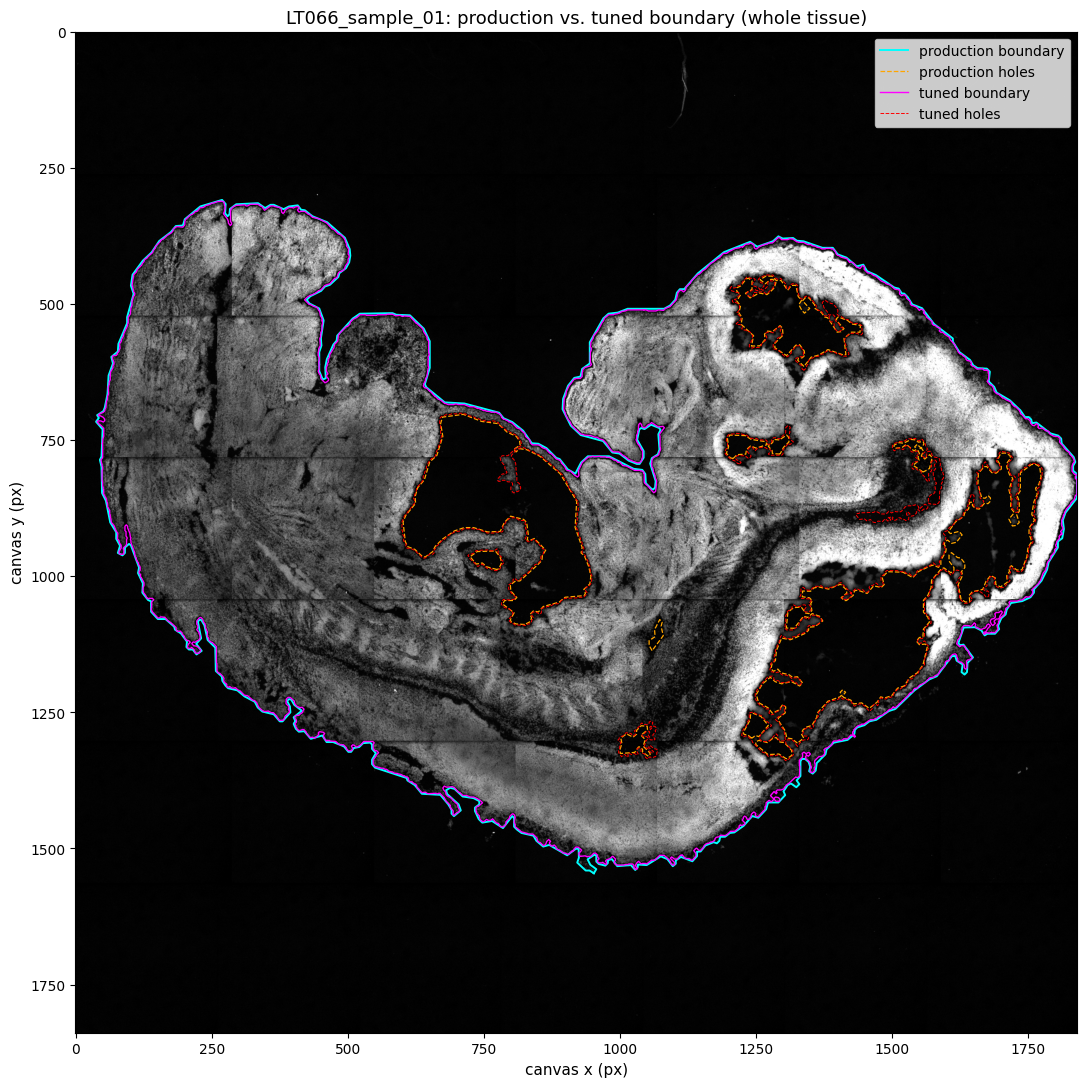

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/tighten_boundary_and_reduce_fov_count/tighten_boundary_and_reduce_fov_count.boundary_comparison_full.png


In [8]:
def plot_both_boundaries(ax, xlim=None, ylim=None):
    covered_vals = canvas.image[canvas.covered]
    ax.imshow(canvas.image, cmap="gray",
              vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))

    bx, by = um_to_px(*boundary_polygon.exterior.xy)
    ax.plot(bx, by, "-", color="cyan", lw=1.4, label="production boundary")
    for hole in hole_polygons:
        hx, hy = um_to_px(*hole.exterior.xy)
        ax.plot(hx, hy, "--", color="orange", lw=0.9)
    ax.plot([], [], "--", color="orange", lw=0.9, label="production holes")

    for tp in tuned_tissue_polygons:
        tbx, tby = um_to_px(*tp.exterior.xy)
        ax.plot(tbx, tby, "-", color="magenta", lw=1.0, label="tuned boundary")
    for hole in tuned_hole_polygons:
        thx, thy = um_to_px(*hole.exterior.xy)
        ax.plot(thx, thy, "--", color="red", lw=0.7)
    ax.plot([], [], "--", color="red", lw=0.7, label="tuned holes")

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=PLOT_LEGEND_FONTSIZE)
    ax.set_xlabel("canvas x (px)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel("canvas y (px)", fontsize=PLOT_LABEL_FONTSIZE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

fig, ax = plt.subplots(figsize=(13, 13))
plot_both_boundaries(ax)
ax.set_title("LT066_sample_01: production vs. tuned boundary (whole tissue)", fontsize=PLOT_TITLE_FONTSIZE)
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.boundary_comparison_full.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.boundary_comparison_full.png')}")

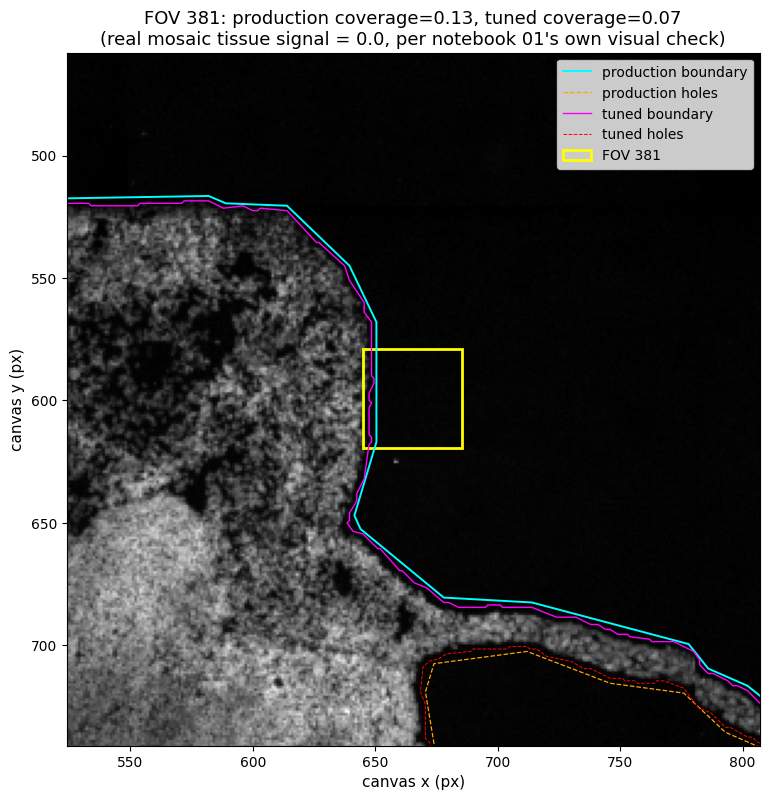

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/tighten_boundary_and_reduce_fov_count/tighten_boundary_and_reduce_fov_count.boundary_comparison_fov381.png


In [9]:
CROP_MARGIN_UM = FOV_SIZE_UM * 3.0  # extra context around FOV 381 itself
c0, r0 = um_to_px(x381 - CROP_MARGIN_UM - half, y381 - CROP_MARGIN_UM - half)
c1, r1 = um_to_px(x381 + CROP_MARGIN_UM + half, y381 + CROP_MARGIN_UM + half)
r0i, r1i = sorted((int(round(r0)), int(round(r1))))
c0i, c1i = sorted((int(round(c0)), int(round(c1))))

fig, ax = plt.subplots(figsize=(9, 9))
plot_both_boundaries(ax, xlim=(c0i, c1i), ylim=(r1i, r0i))

fpx, fpy = um_to_px(x381, y381)
rect = plt.Rectangle((float(fpx) - half_px, float(fpy) - half_px), 2 * half_px, 2 * half_px,
                      fill=False, edgecolor="yellow", lw=2.0, label="FOV 381")
ax.add_patch(rect)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=PLOT_LEGEND_FONTSIZE)

ax.set_title(f"FOV {fov_id_check}: production coverage={cov_prod_381:.2f}, tuned coverage={cov_tuned_381:.2f}\n"
             f"(real mosaic tissue signal = 0.0, per notebook 01's own visual check)",
             fontsize=PLOT_TITLE_FONTSIZE)
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.boundary_comparison_fov381.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.boundary_comparison_fov381.png')}")

## 6 — Recompute geometric coverage against the tightened boundary

Section 3's `coverage_df` was computed against the *production* boundary
(`effective_tissue`, `MARGIN_UM=10` + coarser morphology). Now that a
tightened boundary exists (`tuned_effective_tissue`, section 4), recompute
each real FOV's geometric coverage against it -- this is what section 7's
FOV-count-reduction question below actually needs, so that a "safe to
drop" decision reflects the more accurate boundary rather than the
buffered one.

In [10]:
COVERAGE_TUNED_CSV = CACHE_DIR / "geometric_coverage_per_fov_tuned.csv"

if COVERAGE_TUNED_CSV.exists():
    coverage_df_tuned = pd.read_csv(COVERAGE_TUNED_CSV)
    print(f"Loaded cached {COVERAGE_TUNED_CSV} ({len(coverage_df_tuned)} FOVs).")
else:
    rows = []
    for fov_id, info in meta.fovs.items():
        x, y = info.position
        fov_poly = shapely_box(x - half, y - half, x + half, y + half)
        cov = fov_poly.intersection(tuned_effective_tissue).area / fov_poly.area
        rows.append({"fov_id": fov_id, "x": x, "y": y, "coverage_fraction": cov})
    coverage_df_tuned = pd.DataFrame(rows).sort_values("fov_id").reset_index(drop=True)
    coverage_df_tuned.to_csv(COVERAGE_TUNED_CSV, index=False)
    print(f"Computed and cached {COVERAGE_TUNED_CSV} ({len(coverage_df_tuned)} FOVs).")

diff = (coverage_df_tuned["coverage_fraction"] - coverage_df["coverage_fraction"]).abs()
print(f"FOVs with |tuned - production| coverage change > 0.05: {(diff > 0.05).sum()} / {len(diff)}")
print(f"Mean |tuned - production| coverage change: {diff.mean():.4f}")

Loaded cached /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/analysis/cache/tighten_boundary_and_reduce_fov_count/geometric_coverage_per_fov_tuned.csv (1138 FOVs).
FOVs with |tuned - production| coverage change > 0.05: 226 / 1138
Mean |tuned - production| coverage change: 0.0248


## 7 — How much could the real FOV count have been reduced?

Same two calculations as before (fresh regular/irregular grid
re-optimization, and a hard coverage-threshold filter on the real grid),
but now run against the **tightened** boundary from section 4/6, printed
side by side with the original numbers against the **production**
boundary (already cached from the earlier investigation) -- directly
answering whether a reduction that looked safe against the coarser,
buffered boundary is still safe (or even safer) against the more accurate
one.

In [11]:
FRESH_GRIDS_JSON = CACHE_DIR / "fresh_grid_comparison.json"  # production boundary (cached earlier)
FRESH_GRIDS_TUNED_JSON = CACHE_DIR / "fresh_grid_comparison_tuned.json"  # tuned boundary

fresh_prod = json.loads(FRESH_GRIDS_JSON.read_text())

if FRESH_GRIDS_TUNED_JSON.exists():
    fresh_tuned = json.loads(FRESH_GRIDS_TUNED_JSON.read_text())
else:
    result_regular_tuned = optimize_grid_offset(
        tuned_boundary_polygon, tuned_hole_polygons, STEP_SIZE_UM, FOV_SIZE_UM,
        n_samples=GRID_OFFSET_SAMPLES, low_coverage_fraction=LOW_COVERAGE_FRACTION,
    )
    result_irregular_tuned = optimize_irregular_grid(
        tuned_boundary_polygon, tuned_hole_polygons, STEP_SIZE_UM, FOV_SIZE_UM, n_samples=GRID_OFFSET_SAMPLES,
    )
    fresh_tuned = {
        "regular_n_fovs": result_regular_tuned.best.n_fovs,
        "regular_n_low_coverage_fovs": result_regular_tuned.best.n_low_coverage_fovs,
        "irregular_n_fovs": len(result_irregular_tuned.coords),
    }
    FRESH_GRIDS_TUNED_JSON.write_text(json.dumps(fresh_tuned, indent=2))

n_real = len(coverage_df)
print(f"{'':42s}{'n_fovs':>10s}{'vs real':>10s}")
print(f"{'REAL saved grid':42s}{n_real:>10d}{'--':>10s}")
print(f"{'Fresh REGULAR, production boundary':42s}{fresh_prod['regular_n_fovs']:>10d}{fresh_prod['regular_n_fovs']-n_real:>+10d}")
print(f"{'Fresh REGULAR, tuned boundary':42s}{fresh_tuned['regular_n_fovs']:>10d}{fresh_tuned['regular_n_fovs']-n_real:>+10d}")
print(f"{'Fresh IRREGULAR, production boundary':42s}{fresh_prod['irregular_n_fovs']:>10d}{fresh_prod['irregular_n_fovs']-n_real:>+10d}")
print(f"{'Fresh IRREGULAR, tuned boundary':42s}{fresh_tuned['irregular_n_fovs']:>10d}{fresh_tuned['irregular_n_fovs']-n_real:>+10d}")

                                              n_fovs   vs real
REAL saved grid                                 1138        --
Fresh REGULAR, production boundary              1123       -15
Fresh REGULAR, tuned boundary                   1117       -21
Fresh IRREGULAR, production boundary            1116       -22
Fresh IRREGULAR, tuned boundary                 1101       -37


In [12]:
THRESHOLDS = [0.0, 0.10, 0.25, 0.50]
real_coords = coverage_df[["x", "y"]].to_numpy()

OPTION_B_CSV = CACHE_DIR / "option_b_hard_filter_on_real_grid.csv"  # production boundary (cached earlier)
OPTION_B_TUNED_CSV = CACHE_DIR / "option_b_hard_filter_on_real_grid_tuned.csv"  # tuned boundary

option_b_df = pd.read_csv(OPTION_B_CSV)

if OPTION_B_TUNED_CSV.exists():
    option_b_tuned_df = pd.read_csv(OPTION_B_TUNED_CSV)
else:
    tuned_tissue_area_um2 = tuned_effective_tissue.area
    rows_b = []
    for thresh in THRESHOLDS:
        keep = coverage_df_tuned["coverage_fraction"].to_numpy() >= thresh
        kept_coords = real_coords[keep]
        covered_union = unary_union([
            shapely_box(x - half, y - half, x + half, y + half) for x, y in kept_coords
        ]) if len(kept_coords) else None
        tissue_covered_um2 = covered_union.intersection(tuned_effective_tissue).area if covered_union is not None else 0.0
        rows_b.append({
            "min_coverage_fraction": thresh, "n_fovs_kept": int(keep.sum()),
            "n_fovs_dropped": int((~keep).sum()),
            "tissue_covered_pct": 100 * tissue_covered_um2 / tuned_tissue_area_um2,
        })
    option_b_tuned_df = pd.DataFrame(rows_b)
    option_b_tuned_df.to_csv(OPTION_B_TUNED_CSV, index=False)

print("Option B -- hard geometric-coverage threshold on the REAL grid's real phase (post-hoc):")
print("\nAgainst the PRODUCTION boundary:")
print(option_b_df.to_string(index=False))
print("\nAgainst the TUNED (tightened) boundary:")
print(option_b_tuned_df.to_string(index=False))

merged = option_b_df.merge(option_b_tuned_df, on="min_coverage_fraction", suffixes=("_production", "_tuned"))
merged["tissue_covered_pct_delta"] = merged["tissue_covered_pct_tuned"] - merged["tissue_covered_pct_production"]
print("\nDelta (tuned - production) in tissue_covered_pct at each threshold:")
print(merged[["min_coverage_fraction", "tissue_covered_pct_production", "tissue_covered_pct_tuned", "tissue_covered_pct_delta"]].to_string(index=False))

Option B -- hard geometric-coverage threshold on the REAL grid's real phase (post-hoc):

Against the PRODUCTION boundary:
 min_coverage_fraction  n_fovs_kept  n_fovs_dropped  tissue_covered_pct
                  0.00         1138               0          100.000000
                  0.10         1064              74           99.949808
                  0.25         1011             127           99.401014
                  0.50          930             208           96.888107

Against the TUNED (tightened) boundary:
 min_coverage_fraction  n_fovs_kept  n_fovs_dropped  tissue_covered_pct
                  0.00         1138               0           99.986762
                  0.10         1046              92           99.890418
                  0.25          987             151           99.163873
                  0.50          896             242           95.999577

Delta (tuned - production) in tissue_covered_pct at each threshold:
 min_coverage_fraction  tissue_covered_pct_produ

## 8 — Which real FOVs get dropped, old boundary vs. new (tuned) boundary

Using the same 50%-coverage hard-filter threshold as this notebook's own
headline Option B case (section 7), compare the two possible "reduced"
position sets directly: which real FOVs would be kept under the
*production* boundary's coverage vs. under the *tuned* boundary's
coverage. Overlaid on the mosaic, highlighting FOVs that were kept under
the old (production) boundary but are lost once the tuned boundary is
used instead.

In [13]:
SELECTED_THRESHOLD = 0.50  # same headline case as section 7's Option B

keep_prod = coverage_df["coverage_fraction"].to_numpy() >= SELECTED_THRESHOLD
keep_tuned = coverage_df_tuned["coverage_fraction"].to_numpy() >= SELECTED_THRESHOLD

category = np.full(len(coverage_df), "dropped in both", dtype=object)
category[keep_prod & keep_tuned] = "kept in both"
category[keep_prod & ~keep_tuned] = "lost in new (tuned) boundary"
category[~keep_prod & keep_tuned] = "gained in new (tuned) boundary"

for label in ["kept in both", "lost in new (tuned) boundary",
              "gained in new (tuned) boundary", "dropped in both"]:
    print(f"{label:32s}: {(category == label).sum()}")

kept in both                    : 896
lost in new (tuned) boundary    : 34
gained in new (tuned) boundary  : 0
dropped in both                 : 208


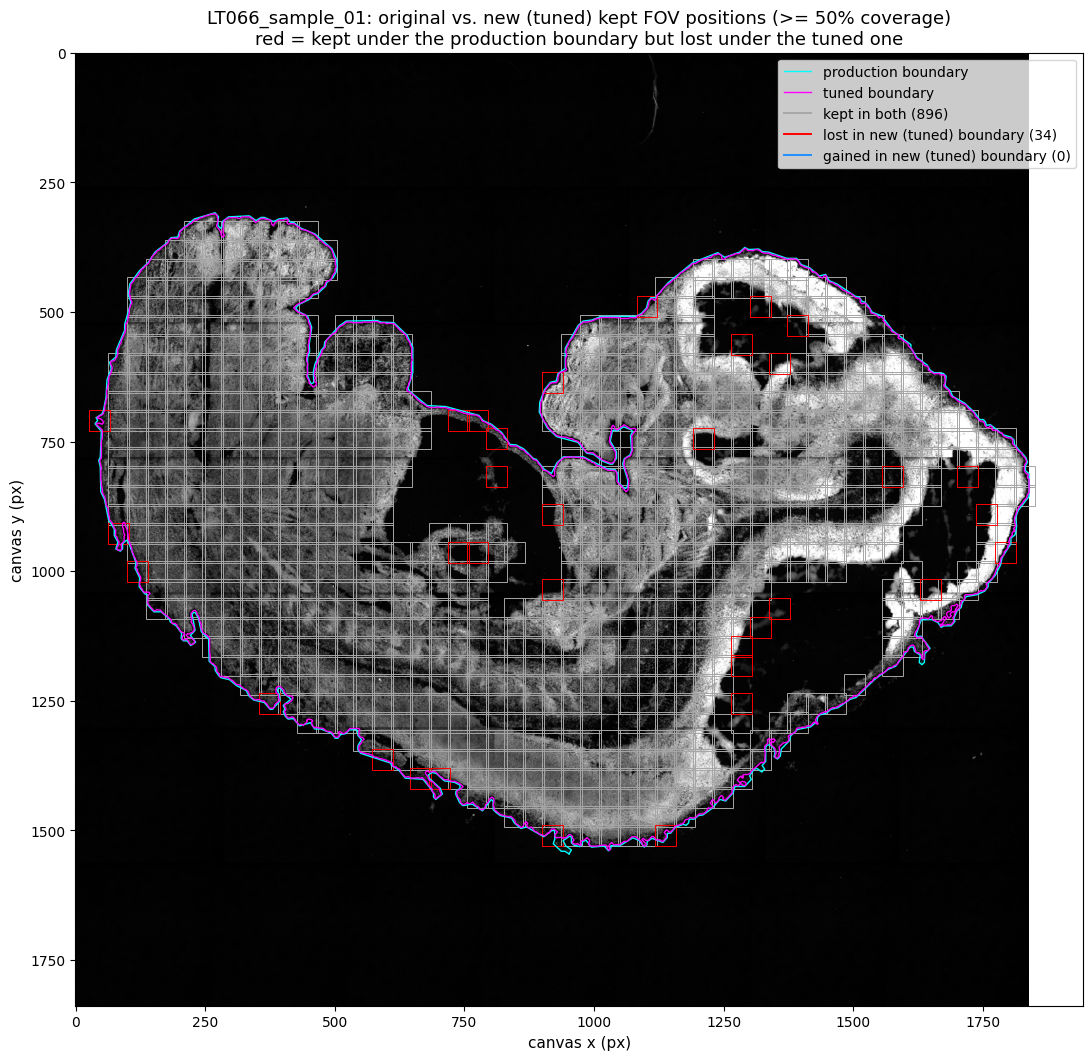

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/tighten_boundary_and_reduce_fov_count/tighten_boundary_and_reduce_fov_count.old_vs_new_positions.png


In [14]:
CATEGORY_COLORS = {
    "kept in both": "0.65",
    "lost in new (tuned) boundary": "red",
    "gained in new (tuned) boundary": "dodgerblue",
}  # "dropped in both" not drawn -- excluded from both position sets already

fig, ax = plt.subplots(figsize=(13, 13))
covered_vals = canvas.image[canvas.covered]
ax.imshow(canvas.image, cmap="gray",
          vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))

bx, by = um_to_px(*boundary_polygon.exterior.xy)
ax.plot(bx, by, "-", color="cyan", lw=1.0, label="production boundary")
tbx, tby = um_to_px(*tuned_boundary_polygon.exterior.xy)
ax.plot(tbx, tby, "-", color="magenta", lw=1.0, label="tuned boundary")

xy = coverage_df[["x", "y"]].to_numpy()
for label, color in CATEGORY_COLORS.items():
    mask = category == label
    for x, y in xy[mask]:
        px, py = um_to_px(x, y)
        rect = plt.Rectangle((float(px) - half_px, float(py) - half_px), 2 * half_px, 2 * half_px,
                              fill=False, edgecolor=color, lw=0.7)
        ax.add_patch(rect)
    ax.plot([], [], "-", color=color, lw=1.4, label=f"{label} ({mask.sum()})")

ax.legend(loc="upper right", fontsize=PLOT_LEGEND_FONTSIZE)
ax.set_title(f"LT066_sample_01: original vs. new (tuned) kept FOV positions "
             f"(>= {SELECTED_THRESHOLD:.0%} coverage)\nred = kept under the production boundary but lost under the tuned one",
             fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xlabel("canvas x (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("canvas y (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.old_vs_new_positions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.old_vs_new_positions.png')}")

Only the FOVs actually retained ("saved") under the tuned boundary's
50%-coverage filter, on the mosaic -- the reduced position set itself,
with no boundary lines or dropped positions cluttering the view.

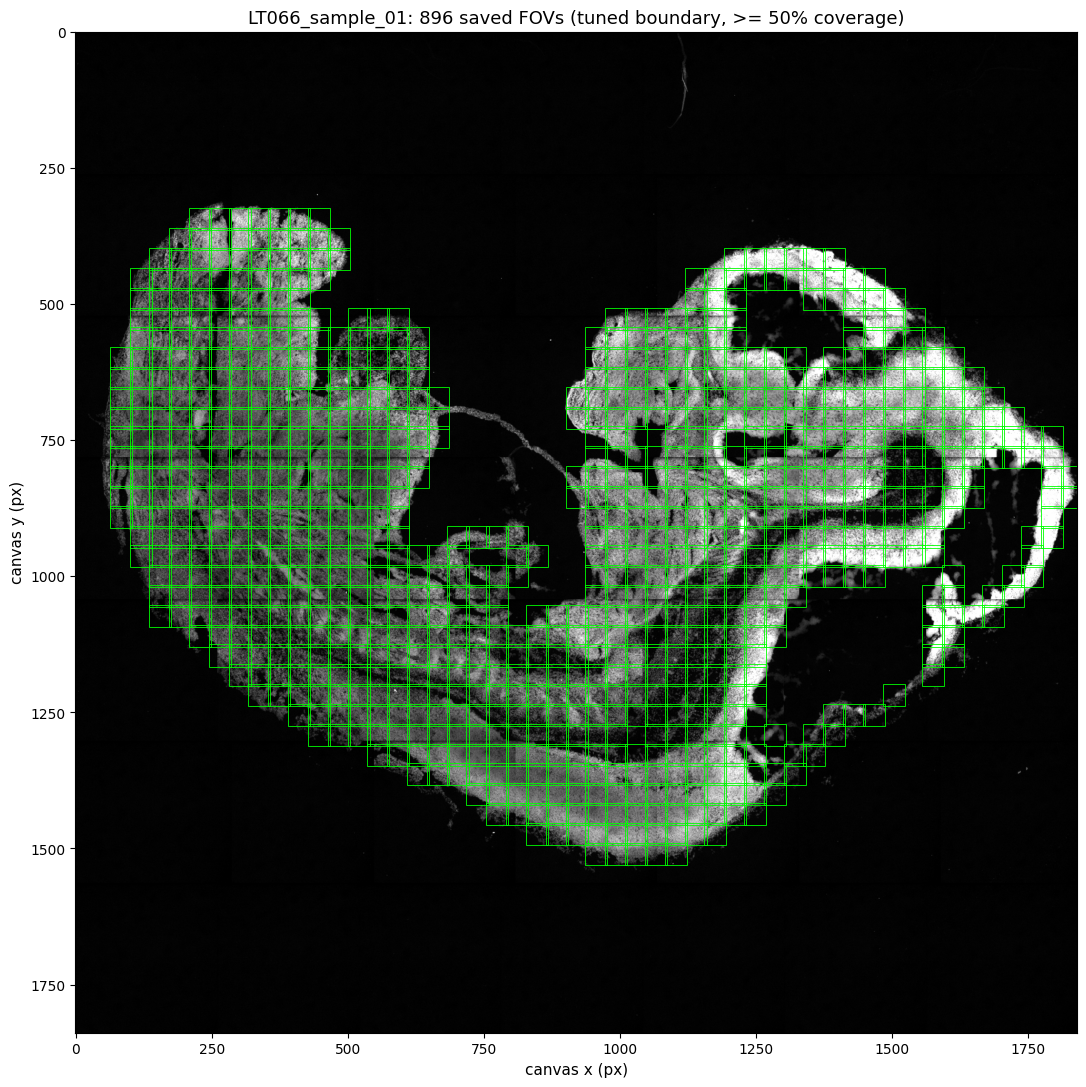

Saved: /n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/LT066_sample_01/merfish/figures/MERci/tests/decrease_fov_number/tighten_boundary_and_reduce_fov_count/tighten_boundary_and_reduce_fov_count.saved_fovs_only.png


In [15]:
fig, ax = plt.subplots(figsize=(13, 13))
ax.imshow(canvas.image, cmap="gray",
          vmin=np.percentile(covered_vals, 1), vmax=np.percentile(covered_vals, 99))

for x, y in xy[keep_tuned]:
    px, py = um_to_px(x, y)
    rect = plt.Rectangle((float(px) - half_px, float(py) - half_px), 2 * half_px, 2 * half_px,
                          fill=False, edgecolor="lime", lw=0.6)
    ax.add_patch(rect)

ax.set_title(f"LT066_sample_01: {int(keep_tuned.sum())} saved FOVs "
             f"(tuned boundary, >= {SELECTED_THRESHOLD:.0%} coverage)", fontsize=PLOT_TITLE_FONTSIZE)
ax.set_xlabel("canvas x (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("canvas y (px)", fontsize=PLOT_LABEL_FONTSIZE)
ax.tick_params(labelsize=PLOT_TICK_FONTSIZE)
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.saved_fovs_only.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / (NOTEBOOK_NAME + '.saved_fovs_only.png')}")

## Takeaways so far

- **The traced boundary itself has real room to tighten** (section 4-5):
  `MARGIN_UM` is the direct buffer control; `CLOSE_RADIUS_UM`/
  `OPEN_RADIUS_UM`/`SIMPLIFY_TOL_UM` control granularity of the outer
  edge. Tightening all of them (still single-piece, no fragmentation)
  moved FOV 381's geometric coverage from 0.131 down to 0.073, closer to
  its real mosaic tissue signal of 0.0 -- a tighter boundary makes
  geometric coverage itself a more accurate proxy, before any grid/filter
  step.
- **Holes need their own size floor, separate from granularity.**
  Recovering small real holes by lowering `MIN_HOLE_AREA_UM2` alone
  (first attempt: `2_000` um^2) also recovered a long tail of holes
  smaller than a single FOV's own footprint (~0.041 mm^2) -- too small to
  matter for FOV placement, and confounding the section 7 comparison
  below with extra spurious low-coverage FOVs. **New rule: only keep
  holes >= one FOV's area** (`min_hole_area_um2 = FOV_SIZE_UM ** 2`).
  This drops the tuned hole count from 76 to 9 (fewer even than
  production's 11 -- 2 of production's own holes are themselves smaller
  than one FOV) and recovers effective-tissue area (29.21 -> 29.74 mm^2),
  while the outer boundary itself (vertices, FOV 381 coverage) is
  unaffected, since holes and the outer contour are filtered
  independently.
- **Grid-shape/phase optimization alone still buys little** (section 7),
  against either boundary: fresh REGULAR/IRREGULAR grids save only
  15-37 FOVs out of 1138 (1-3%), consistent with
  `02_compare_fov_coverage_constraint.ipynb`'s own finding on a different
  real boundary.
- **Answering the actual question this section was redone for**: at the
  50%-coverage hard-filter threshold (the ~20%-of-FOVs-dropped case),
  tightening the boundary (with the one-FOV hole-area floor applied)
  still does **not** move the covered-tissue number closer to 100% -- it's
  slightly *lower* against the tuned boundary (96.0% vs. 96.9% against
  production), not higher, though the gap narrowed from -1.01 to -0.89
  points once the sub-FOV holes were excluded. The remaining gap comes
  from real holes >= one FOV near the tissue edge, which do genuinely lower
  coverage for nearby boundary-adjacent FOVs; dropping them at a hard
  threshold loses a bit more real tissue, not less. So the earlier 96.9%
  number was not an underestimate caused by boundary coarseness -- if
  anything the coarser production boundary was mildly *optimistic*.
- No changes made yet to `acquisition/positions.py` or the production
  `02_create_boundary_from_mosaic.ipynb` defaults -- this is still an
  investigation. Next steps to be scoped by the user.